In [ ]:
# Amazon Reviews Analytics

#Section 1 — Dataset Overview

'''

This notebook analyzes the Amazon Fine Food Reviews dataset and extracts
user, product, rating, and temporal insights.

The analysis focuses on:

- Dataset scale and structure
- Data quality
- Rating behavior
- User activity
- Product engagement
- Temporal trends
- Recommendation-system sparsity
- Business insights

'''

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt


# Project root
BASE_DIR = os.path.dirname(
    os.path.abspath(os.getcwd())
)

DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "Reviews.csv"
)

print("Project root:", BASE_DIR)
print("Dataset path:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Project root: c:\Users\sid\Desktop\Study and Work Mega Folder\Projects\amazon_recommendation_system
Dataset path: c:\Users\sid\Desktop\Study and Work Mega Folder\Projects\amazon_recommendation_system\data\raw\Reviews.csv

Dataset loaded successfully.
Rows: 568,454
Columns: 10


In [5]:
#dataset structure
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape:
(568454, 10)

Columns:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

First 5 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
#DATA STATISTICS

total_reviews = len(df)
unique_users = df["UserId"].nunique()
unique_products = df["ProductId"].nunique()

average_rating = df["Score"].mean()
median_rating = df["Score"].median()

print("DATASET OVERVIEW")
print("-" * 50)

print(f"Total reviews:       {total_reviews:,}")
print(f"Unique users:        {unique_users:,}")
print(f"Unique products:     {unique_products:,}")
print(f"Average rating:      {average_rating:.2f}")
print(f"Median rating:       {median_rating:.1f}")

DATASET OVERVIEW
--------------------------------------------------
Total reviews:       568,454
Unique users:        256,059
Unique products:     74,258
Average rating:      4.18
Median rating:       5.0


In [ ]:
## SECTION 2: Rating Analysis

'''
We analyze the distribution of product ratings to understand overall
customer sentiment and identify potential rating imbalance in the dataset.

'''

In [7]:
#analysing ratings
rating_counts = (
    df["Score"]
    .value_counts()
    .sort_index()
)

rating_percentages = (
    rating_counts / len(df) * 100
)

rating_summary = pd.DataFrame({
    "review_count": rating_counts,
    "percentage": rating_percentages.round(2)
})

display(rating_summary)

,review_count,percentage
Score,,
1,52268,9.19
2,29769,5.24
3,42640,7.50
4,80655,14.19
5,363122,63.88


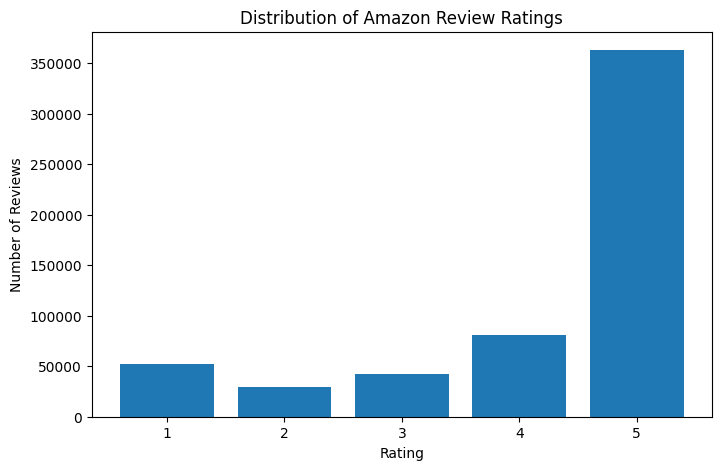

In [8]:
#rating visualization

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Amazon Review Ratings")

plt.show()

In [9]:
#CALCULATING POSITIVE AND NEGATIVE REVIEWS

positive_reviews = (df["Score"] >= 4).sum()
negative_reviews = (df["Score"] <= 2).sum()

positive_percentage = positive_reviews / len(df) * 100
negative_percentage = negative_reviews / len(df) * 100

print(f"Positive reviews (4-5): {positive_percentage:.2f}%")
print(f"Negative reviews (1-2): {negative_percentage:.2f}%")

Positive reviews (4-5): 78.07%
Negative reviews (1-2): 14.43%


In [10]:
# SECTION 3: User Behavior

'''
We analyze how review activity is distributed across users.

This helps identify whether interaction activity is evenly distributed
or concentrated among a relatively small number of highly active users.

'''

'\nWe analyze how review activity is distributed across users.\n\nThis helps identify whether interaction activity is evenly distributed\nor concentrated among a relatively small number of highly active users.\n\n'

In [11]:
reviews_per_user = (
    df["UserId"]
    .value_counts()
)

print("Reviews per user:")
print(reviews_per_user.describe())

Reviews per user:
count    256059.000000
mean          2.220012
std           4.443361
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         448.000000
Name: count, dtype: float64


In [12]:
print("Top 10 most active users:")

top_users = (
    reviews_per_user
    .head(10)
    .rename("review_count")
    .reset_index()
)

top_users.columns = ["UserId", "review_count"]

display(top_users)

Top 10 most active users:


,UserId,review_count
0,A3OXHLG6DIBRW8,448
1,A1YUL9PCJR3JTY,421
2,AY12DBB0U420B,389
3,A281NPSIMI1C2R,365
4,A1Z54EM24Y40LL,256
5,A1TMAVN4CEM8U8,204
6,A2MUGFV2TDQ47K,201
7,A3TVZM3ZIXG8YW,199
8,A3PJZ8TU8FDQ1K,178
9,AQQLWCMRNDFGI,176


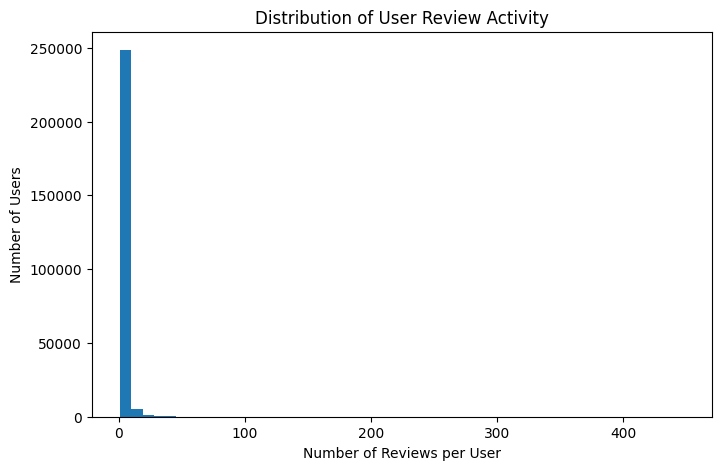

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    reviews_per_user,
    bins=50
)

plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("Distribution of User Review Activity")

plt.show()

In [ ]:
## SECTION 4. Product Behavior

'''
We analyze review volume across products to understand product
engagement and identify highly reviewed products.

'''

In [14]:
reviews_per_product = (
    df["ProductId"]
    .value_counts()
)

print("Reviews per product:")
print(reviews_per_product.describe())

Reviews per product:
count    74258.000000
mean         7.655121
std         26.453485
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        913.000000
Name: count, dtype: float64


In [15]:
# TOP PRODUCTS
top_products = (
    reviews_per_product
    .head(10)
    .rename("review_count")
    .reset_index()
)

top_products.columns = [
    "ProductId",
    "review_count"
]

display(top_products)

,ProductId,review_count
0,B007JFMH8M,913
1,B0026RQTGE,632
2,B002QWHJOU,632
3,B002QWP89S,632
4,B002QWP8H0,632
5,B003B3OOPA,623
6,B001EO5Q64,567
7,B000VK8AVK,564
8,B0026KNQSA,564
9,B007M83302,564


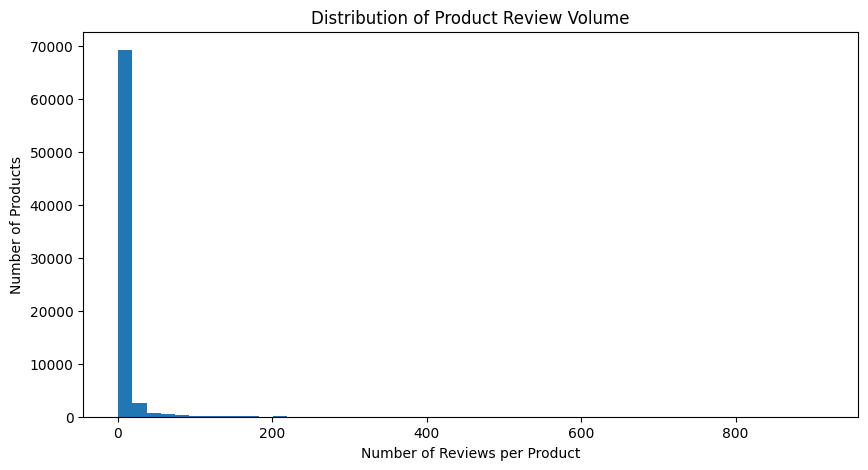

In [16]:
#VISUALIZATION

plt.figure(figsize=(10, 5))

plt.hist(
    reviews_per_product,
    bins=50
)

plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Review Volume")

plt.show()

In [ ]:
# Section 5: Rating vs. Review Volume

In [17]:
# Do highly reviewed products actually have higher ratings?

product_stats = (
    df.groupby("ProductId")
    .agg(
        avg_rating=("Score", "mean"),
        review_count=("Score", "count")
    )
    .reset_index()
)

display(product_stats.head())

print(
    product_stats[
        ["avg_rating", "review_count"]
    ].describe()
)

,ProductId,avg_rating,review_count
0,0006641040,4.351351,37
1,141278509X,5.000000,1
2,2734888454,3.500000,2
3,2841233731,5.000000,1
4,7310172001,4.751445,173


         avg_rating  review_count
count  74258.000000  74258.000000
mean       4.166189      7.655121
std        1.070182     26.453485
min        1.000000      1.000000
25%        3.783784      1.000000
50%        4.500000      2.000000
75%        5.000000      5.000000
max        5.000000    913.000000


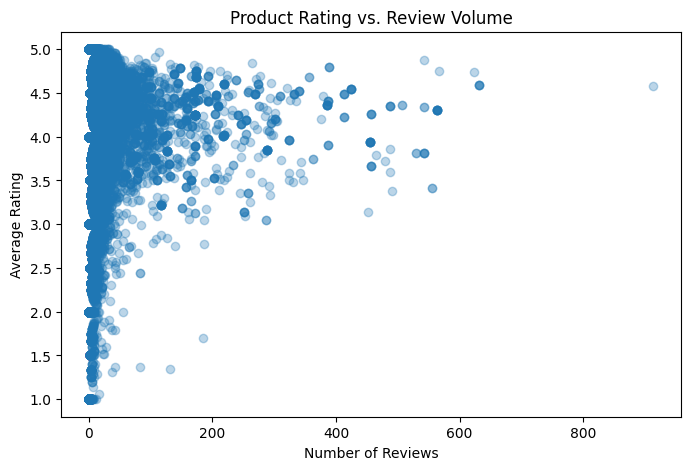

In [18]:
# Plotting

plt.figure(figsize=(8, 5))

plt.scatter(
    product_stats["review_count"],
    product_stats["avg_rating"],
    alpha=0.3
)

plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Product Rating vs. Review Volume")

plt.show()

In [19]:
'''
Products with only 1–2 reviews will make the graph noisy.

So we'll also analyze products with meaningful review volume:

'''

popular_product_stats = product_stats[
    product_stats["review_count"] >= 20
]

print(
    f"Products with at least 20 reviews: "
    f"{len(popular_product_stats):,}"
)

Products with at least 20 reviews: 5,030


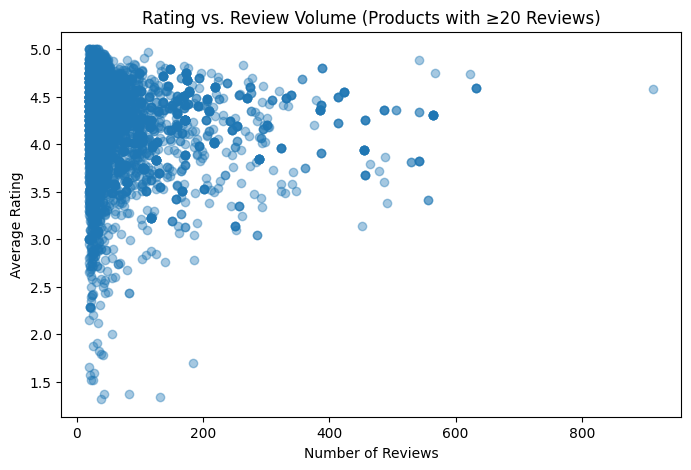

In [20]:
# Plotting

plt.figure(figsize=(8, 5))

plt.scatter(
    popular_product_stats["review_count"],
    popular_product_stats["avg_rating"],
    alpha=0.4
)

plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title(
    "Rating vs. Review Volume "
    "(Products with ≥20 Reviews)"
)

plt.show()

In [ ]:
## 6. Temporal Trends

'''
We analyze review activity over time to identify changes in review volume
and rating behavior across the dataset's time period.

'''

In [21]:
# Convert Unix timestamps to datetime

df["ReviewDate"] = pd.to_datetime(
    df["Time"],
    unit="s"
)

df["ReviewYear"] = df["ReviewDate"].dt.year
df["ReviewMonth"] = df["ReviewDate"].dt.month

In [22]:
# Reviews by Year


reviews_by_year = (
    df["ReviewYear"]
    .value_counts()
    .sort_index()
)

display(
    reviews_by_year
    .rename("review_count")
    .reset_index()
    .rename(columns={"index": "year"})
)

,ReviewYear,review_count
0,1999,6
1,2000,32
2,2001,13
3,2002,73
4,2003,132
5,2004,561
6,2005,1335
7,2006,6671
8,2007,22300
9,2008,34163


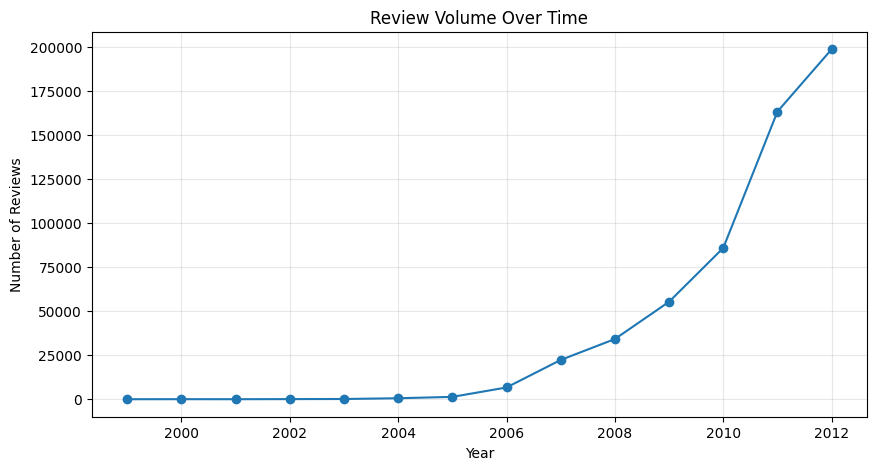

In [23]:
# Plotting

plt.figure(figsize=(10, 5))

plt.plot(
    reviews_by_year.index,
    reviews_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Review Volume Over Time")

plt.grid(True, alpha=0.3)

plt.show()

In [24]:
#Average Rating by Year

rating_by_year = (
    df.groupby("ReviewYear")["Score"]
    .mean()
)

display(
    rating_by_year
    .round(3)
    .rename("average_rating")
    .reset_index()
)

,ReviewYear,average_rating
0,1999,5.000
1,2000,4.531
2,2001,3.538
3,2002,4.712
4,2003,4.326
5,2004,4.392
6,2005,4.446
7,2006,4.313
8,2007,4.391
9,2008,4.345


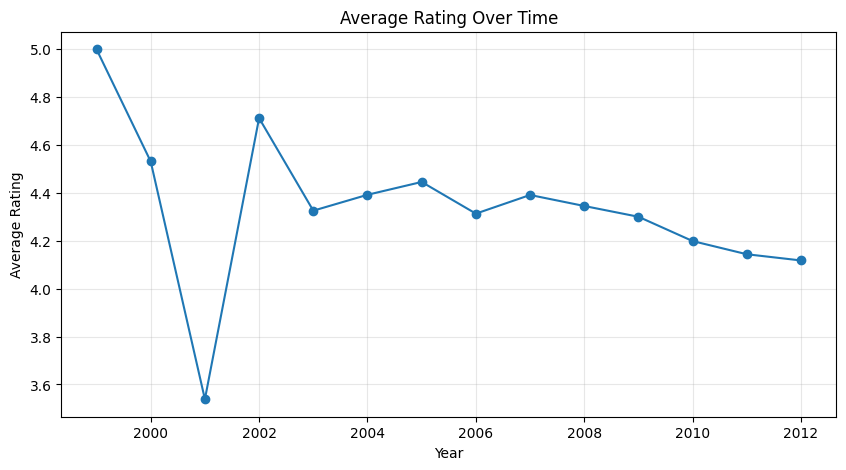

In [25]:
#Plotting

plt.figure(figsize=(10, 5))

plt.plot(
    rating_by_year.index,
    rating_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time")

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
## 7. Recommendation-System Sparsity

'''
The user-product interaction matrix is highly sparse because most users
interact with only a small number of products.

We analyze the sparsity of the raw interaction matrix and then examine
how minimum-interaction filtering affects the size of the dataset.

'''

In [26]:
# User-product interaction statistics

user_review_counts = df["UserId"].value_counts()
product_review_counts = df["ProductId"].value_counts()

print("RAW DATASET")
print("-" * 50)

print(f"Users:             {df['UserId'].nunique():,}")
print(f"Products:          {df['ProductId'].nunique():,}")
print(f"Interactions:      {len(df):,}")

total_possible = (
    df["UserId"].nunique()
    * df["ProductId"].nunique()
)

sparsity = (
    1 - len(df) / total_possible
) * 100

print(f"Possible interactions: {total_possible:,}")
print(f"Sparsity:              {sparsity:.4f}%")

RAW DATASET
--------------------------------------------------
Users:             256,059
Products:          74,258
Interactions:      568,454
Possible interactions: 19,014,429,222
Sparsity:              99.9970%


In [27]:
#reproducing the filtering strategy form the original code

# Keep users with at least 5 reviews
active_users = user_review_counts[
    user_review_counts >= 5
].index

filtered_df = df[
    df["UserId"].isin(active_users)
]

# Keep products with at least 5 reviews
active_products = (
    filtered_df["ProductId"]
    .value_counts()
)

active_products = active_products[
    active_products >= 5
].index

filtered_df = filtered_df[
    filtered_df["ProductId"].isin(active_products)
]

print("AFTER MINIMUM-5 INTERACTION FILTERING")
print("-" * 50)

print(f"Reviews:            {len(filtered_df):,}")
print(f"Users:              {filtered_df['UserId'].nunique():,}")
print(f"Products:           {filtered_df['ProductId'].nunique():,}")

AFTER MINIMUM-5 INTERACTION FILTERING
--------------------------------------------------
Reviews:            195,807
Users:              22,692
Products:           6,544


In [29]:
# CALCULATING THE RESULTING SPARSITY

filtered_possible = (
    filtered_df["UserId"].nunique()
    * filtered_df["ProductId"].nunique()
)

filtered_sparsity = (
    1 - len(filtered_df) / filtered_possible
) * 100

print(f"Possible interactions: {filtered_possible:,}")
print(f"Sparsity:              {filtered_sparsity:.4f}%")

Possible interactions: 148,496,448
Sparsity:              99.8681%


# 8. Key Insights

The analysis of 568K+ Amazon reviews reveals several important patterns
that directly influence the design of the recommendation system.


## 8.1 Dataset Characteristics

- The dataset contains **568,454 reviews** from **256,059 users** across
  **74,258 products**.
- The overall average rating is **4.18**, while the median rating is **5.0**.
- **63.88%** of all reviews are 5-star ratings and **78.07%** are 4- or
  5-star ratings, indicating a strong positive-rating bias.


## 8.2 User and Product Activity

- User activity is highly skewed. The median user contributes only
  **1 review**, while the most active user contributes **448 reviews**.
- Product activity is similarly skewed. The median product has only
  **2 reviews**, while the most reviewed product has **913 reviews**.
- This long-tail behavior means that most user-product interactions contain
  relatively little information, while a small number of users and products
  account for a large share of interactions.


## 8.3 Temporal Trends

- Review activity increased dramatically over the dataset's time period.
- Review volume grew from only **6 reviews in 1999** to **198,659 reviews
  in 2012**.
- Review activity is heavily concentrated in the later years, particularly
  2011 and 2012.
- Average rating also declined gradually during the later period, from
  approximately **4.39 in 2007** to **4.12 in 2012**.
- This represents an observed temporal trend rather than evidence of a
  causal relationship.


## 8.4 Recommendation-System Sparsity

The raw user-product interaction space contains approximately **19 billion
possible interactions**, but only **568,454 observed interactions**.

This results in approximately **99.997% sparsity**.

Applying a minimum interaction threshold reduces the dataset to:

- **195,807 interactions**
- **22,692 users**
- **6,544 products**

The interaction matrix remains sparse, but the filtering substantially
reduces the dimensionality and removes users and products with very limited
interaction history.

This preprocessing is particularly important for collaborative filtering,
where insufficient interaction data makes similarity-based recommendations
less reliable.


## 8.5 Implications for Recommendation Design

The analysis motivates the use of multiple recommendation strategies:

1. **Popularity-based recommendation**
   - Provides a useful baseline and can recommend products even when there
     is insufficient personalized interaction data.

2. **Collaborative filtering**
   - Can capture relationships between products based on user interaction
     patterns.
   - Requires interaction filtering because the raw user-product matrix is
     extremely sparse.

3. **Content-based recommendation**
   - Uses product review text and TF-IDF similarity to identify products
     with similar textual characteristics.
   - Provides an alternative signal when collaborative interaction data is
     limited.

4. **Weighted product ranking**
   - Average rating alone can overvalue products with very few reviews.
   - Combining rating quality with review volume provides a more reliable
     product ranking.



## 8.6 Summary

The dataset exhibits three dominant characteristics:

- **Strong positive-rating bias**
- **Highly skewed user and product activity**
- **Extreme user-product interaction sparsity**

These characteristics explain the preprocessing and motivate the use of
multiple recommendation approaches rather than relying on a single model.

The resulting pipeline combines data-quality validation, exploratory
analytics, SQL-based analysis, and recommendation models to transform raw
review data into actionable product recommendations.